# Bibliotecas

In [126]:
import pandas as pd
import streamlit as st
import plotly.express as px
import altair as alt
import os
from scipy.stats import pearsonr

# Carregando dados sobre valores de habitação

In [ ]:
@st.cache_data
def load_data():
    df = pd.read_csv("perda_poder_compra_habitacao_2018_2025.csv")
    return df

In [ ]:
df.info()
# Sanity check

<class 'pandas.DataFrame'>
Index: 40 entries, 24 to 7
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pais                       40 non-null     str    
 1   ano                        40 non-null     int64  
 2   preco_medio_habitacao_usd  40 non-null     int64  
 3   salario_medio_anual_usd    40 non-null     int64  
 4   salario_medio_mensal_usd   40 non-null     int64  
 5   inflacao_anual_pct         40 non-null     float64
 6   preco_rendimento_ratio     40 non-null     float64
 7   imigracao_liquida          40 non-null     int64  
 8   populacao_total            40 non-null     int64  
 9   taxa_imigracao_pct         40 non-null     float64
 10  variacao_preco_pct         35 non-null     float64
dtypes: float64(4), int64(6), str(1)
memory usage: 4.0 KB


# Criando filtros

In [87]:
# Filtro de período
ano_inicio, ano_fim = st.select_slider(
    "Selecione o período:",
    options=sorted(df["ano"].unique()),
    value=(df["ano"].min(), df["ano"].max())
)

df_filtrado = df[(df["ano"] >= ano_inicio) & (df["ano"] <= ano_fim)]

# Filtro de países
paises = st.multiselect(
    "Selecione os países:",
    df_filtrado["pais"].unique(),
    default=df_filtrado["pais"].unique()
)

df_filtrado = df_filtrado[df_filtrado["pais"].isin(paises)]

2026-03-22 21:58:29.416 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 21:58:29.417 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 21:58:29.417 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 21:58:29.418 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 21:58:29.419 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 21:58:29.420 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 21:58:29.423 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 21:58:29.424 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
df_filtrado.head()
#Sanity check

,pais,ano,preco_medio_habitacao_usd,salario_medio_anual_usd,salario_medio_mensal_usd,inflacao_anual_pct,preco_rendimento_ratio
0,Portugal,2018,210000,24000,2000,1.2,8.75
1,Portugal,2019,225000,24500,2042,0.3,9.18
2,Portugal,2020,240000,25000,2083,0.0,9.60
3,Portugal,2021,270000,25500,2125,1.3,10.59
4,Portugal,2022,300000,25800,2150,7.8,11.63


# Criando gráficos 

In [ ]:
# Gráfico de linha para o preço médio da habitação ao longo do tempo
grafico_preco = alt.Chart(df_filtrado).mark_line(point=True).encode(
    x="ano:O",
    y="preco_medio_habitacao_usd:Q",
    color="pais:N",
    tooltip=["pais", "ano", "preco_medio_habitacao_usd"]
).properties(
    width='container',
    height=400
).interactive()

st.altair_chart(grafico_preco, use_container_width=True)
grafico_preco

2026-03-22 22:09:39.683 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'` or specify an integer width.
2026-03-22 22:09:39.684 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.684 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.685 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


alt.Chart(...)

In [ ]:
# Gráfico de linha para a inflação anual ao longo do tempo
st.subheader("📊 Evolução da Inflação Anual (%)")

grafico_inflacao = alt.Chart(df_filtrado).mark_line(point=True).encode(
    x="ano:O",
    y="inflacao_anual_pct:Q",
    color="pais:N",
    tooltip=["pais", "ano", "inflacao_anual_pct"]
).properties(
    width='container',
).interactive()

st.altair_chart(grafico_inflacao, use_container_width=True)
grafico_inflacao

2026-03-22 22:09:39.712 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.717 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.718 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.755 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'` or specify an integer width.
2026-03-22 22:09:39.756 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.756 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.757 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored

alt.Chart(...)

In [110]:
st.subheader("💰 Evolução do Salário Médio Anual (USD)")

grafico_salario = alt.Chart(df_filtrado).mark_line(point=True).encode(
    x="ano:O",
    y="salario_medio_anual_usd:Q",
    color="pais:N",
    tooltip=["pais", "ano", "salario_medio_anual_usd"]
).properties(
    width='container',
).interactive()

st.altair_chart(grafico_salario, use_container_width=True)
grafico_salario

2026-03-22 22:09:39.781 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.812 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'` or specify an integer width.
2026-03-22 22:09:39.812 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.813 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.813 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored

alt.Chart(...)

In [111]:
st.subheader("🏠 Indicador de Acessibilidade Habitacional (Preço / Rendimento)")

grafico_ratio = alt.Chart(df_filtrado).mark_line(point=True).encode(
    x="ano:O",
    y="preco_rendimento_ratio:Q",
    color="pais:N",
    tooltip=["pais", "ano", "preco_rendimento_ratio"]
).properties(
    width='container',
).interactive()

st.altair_chart(grafico_ratio, use_container_width=True)
grafico_ratio

2026-03-22 22:09:39.835 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.836 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.836 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.867 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'` or specify an integer width.
2026-03-22 22:09:39.867 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 22:09:39.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored

alt.Chart(...)

# Carregando dados sobre imigração

In [128]:
# carregando dados e modificando nomes das tabelas.
df_poder = pd.read_csv("perda_poder_compra_habitacao_2018_2025.csv")
df_migracao = pd.read_csv("C:/Users/LENOVO i5 Gaming/Desktop/Curso de Analista de dados/migracao.csv")


In [129]:
df_poder.head()
#sanity check

,pais,ano,preco_medio_habitacao_usd,salario_medio_anual_usd,salario_medio_mensal_usd,inflacao_anual_pct,preco_rendimento_ratio
0,Portugal,2018,210000,24000,2000,1.2,8.75
1,Portugal,2019,225000,24500,2042,0.3,9.18
2,Portugal,2020,240000,25000,2083,0.0,9.60
3,Portugal,2021,270000,25500,2125,1.3,10.59
4,Portugal,2022,300000,25800,2150,7.8,11.63


In [130]:
df_migracao.head()
#sanity check

,pais,ano,imigracao_liquida,populacao_total,taxa_imigracao_pct
0,Portugal,2018,22495,10323939,0.22
1,Portugal,2019,63031,10362384,0.61
2,Portugal,2020,54076,10378612,0.52
3,Portugal,2021,69606,10403292,0.67
4,Portugal,2022,68696,10430785,0.66


In [131]:
# Unificando os dados de poder de compra e migração

df_unificado = pd.merge(
    df_poder,
    df_migracao,
    on=["pais", "ano"],
    how="inner"
)

colunas_poder = df_poder.columns.tolist()
colunas_migracao = [col for col in df_migracao.columns if col not in ["pais", "ano"]]

ordem_final = colunas_poder + colunas_migracao
df_unificado = df_unificado[ordem_final]

df_unificado.to_csv("tabela_unificada_poder_compra_migracao.csv", index=False)

print(df_unificado.head())


       pais   ano  preco_medio_habitacao_usd  salario_medio_anual_usd  \
0  Portugal  2018                     210000                    24000   
1  Portugal  2019                     225000                    24500   
2  Portugal  2020                     240000                    25000   
3  Portugal  2021                     270000                    25500   
4  Portugal  2022                     300000                    25800   

   salario_medio_mensal_usd  inflacao_anual_pct  preco_rendimento_ratio  \
0                      2000                 1.2                    8.75   
1                      2042                 0.3                    9.18   
2                      2083                 0.0                    9.60   
3                      2125                 1.3                   10.59   
4                      2150                 7.8                   11.63   

   imigracao_liquida  populacao_total  taxa_imigracao_pct  
0              22495         10323939             

In [132]:
df_unificado.head()

,pais,ano,preco_medio_habitacao_usd,salario_medio_anual_usd,salario_medio_mensal_usd,inflacao_anual_pct,preco_rendimento_ratio,imigracao_liquida,populacao_total,taxa_imigracao_pct
0,Portugal,2018,210000,24000,2000,1.2,8.75,22495,10323939,0.22
1,Portugal,2019,225000,24500,2042,0.3,9.18,63031,10362384,0.61
2,Portugal,2020,240000,25000,2083,0.0,9.60,54076,10378612,0.52
3,Portugal,2021,270000,25500,2125,1.3,10.59,69606,10403292,0.67
4,Portugal,2022,300000,25800,2150,7.8,11.63,68696,10430785,0.66


# Gerando um Heatmap para vizualização.

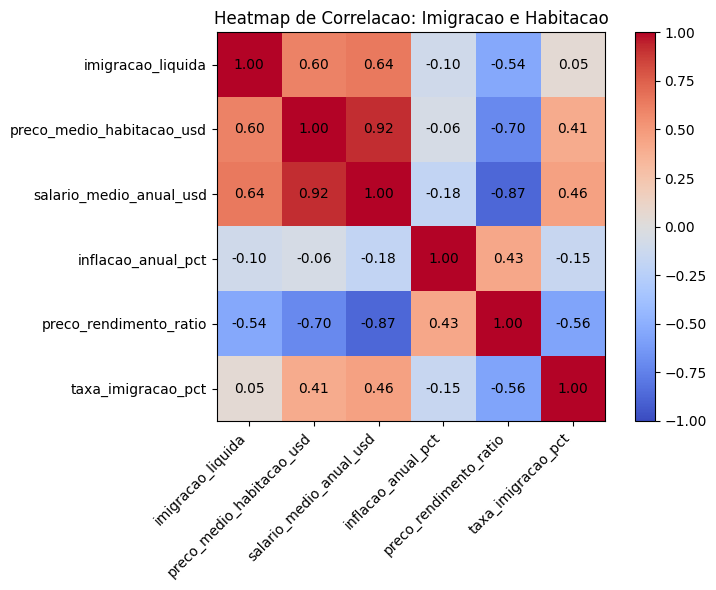

In [133]:
# Heatmap de correlação entre as variáveis

colunas = [
    "imigracao_liquida",
    "preco_medio_habitacao_usd",
    "salario_medio_anual_usd",
    "inflacao_anual_pct",
    "preco_rendimento_ratio",
    "taxa_imigracao_pct"
]

corr = df[colunas].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(colunas)))
ax.set_yticks(range(len(colunas)))
ax.set_xticklabels(colunas, rotation=45, ha="right")
ax.set_yticklabels(colunas)

for i in range(len(colunas)):
    for j in range(len(colunas)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Heatmap de Correlacao: Imigracao e Habitacao")
fig.colorbar(im)
plt.tight_layout()
plt.show()


# Gerando Gráficos

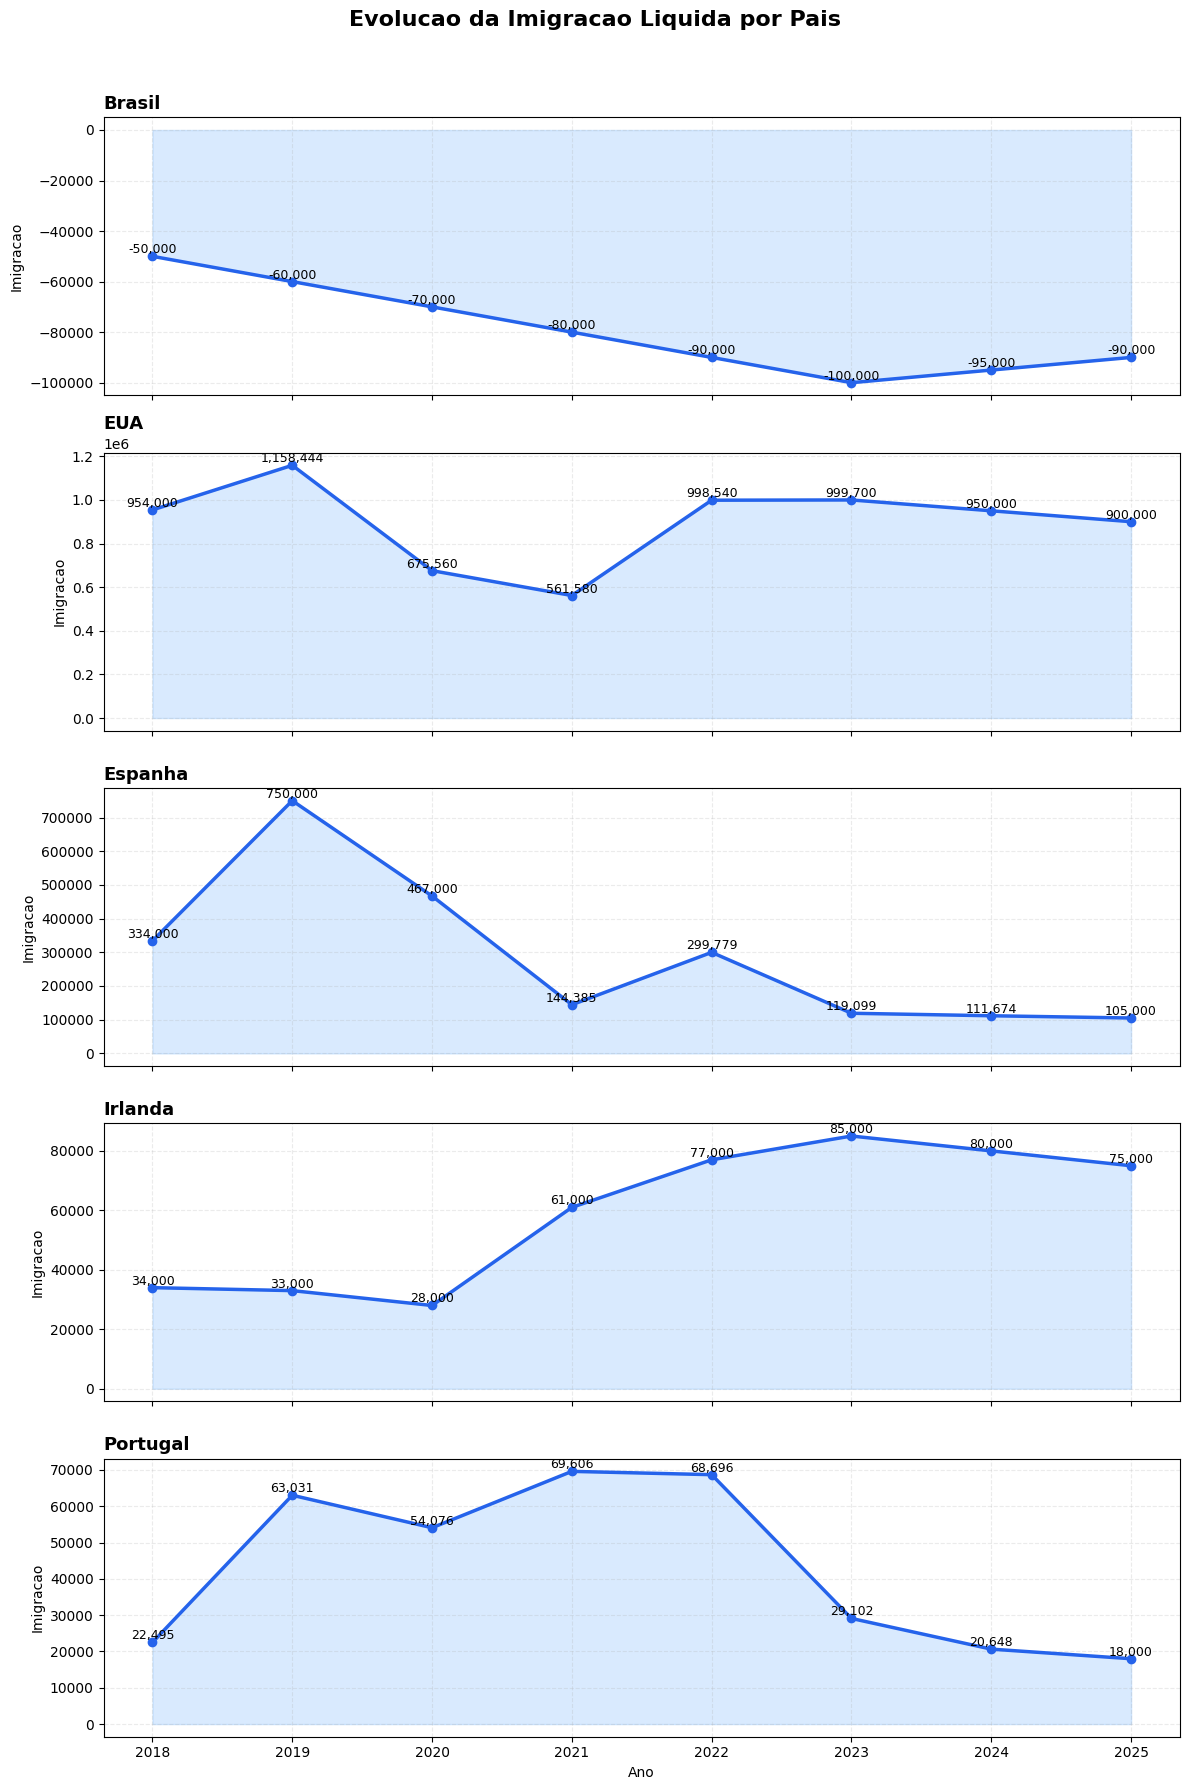

In [134]:
# Gráfico combinado: Imigracao em barras e Preco da Habitacao em linha
paises = df["pais"].unique()

fig, axes = plt.subplots(len(paises), 1, figsize=(12, 3.5 * len(paises)), sharex=True)

if len(paises) == 1:
    axes = [axes]

for ax, pais in zip(axes, paises):
    df_pais = df[df["pais"] == pais].sort_values("ano")

    ax.plot(
        df_pais["ano"],
        df_pais["imigracao_liquida"],
        color="#2563eb",
        marker="o",
        linewidth=2.5
    )

    ax.fill_between(
        df_pais["ano"],
        df_pais["imigracao_liquida"],
        color="#93c5fd",
        alpha=0.35
    )

    ax.set_title(pais, loc="left", fontsize=13, weight="bold")
    ax.set_ylabel("Imigracao")
    ax.grid(True, linestyle="--", alpha=0.25)

    for x, y in zip(df_pais["ano"], df_pais["imigracao_liquida"]):
        ax.text(x, y, f"{int(y):,}", fontsize=9, ha="center", va="bottom")

axes[-1].set_xlabel("Ano")
plt.suptitle("Evolucao da Imigracao Liquida por Pais", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


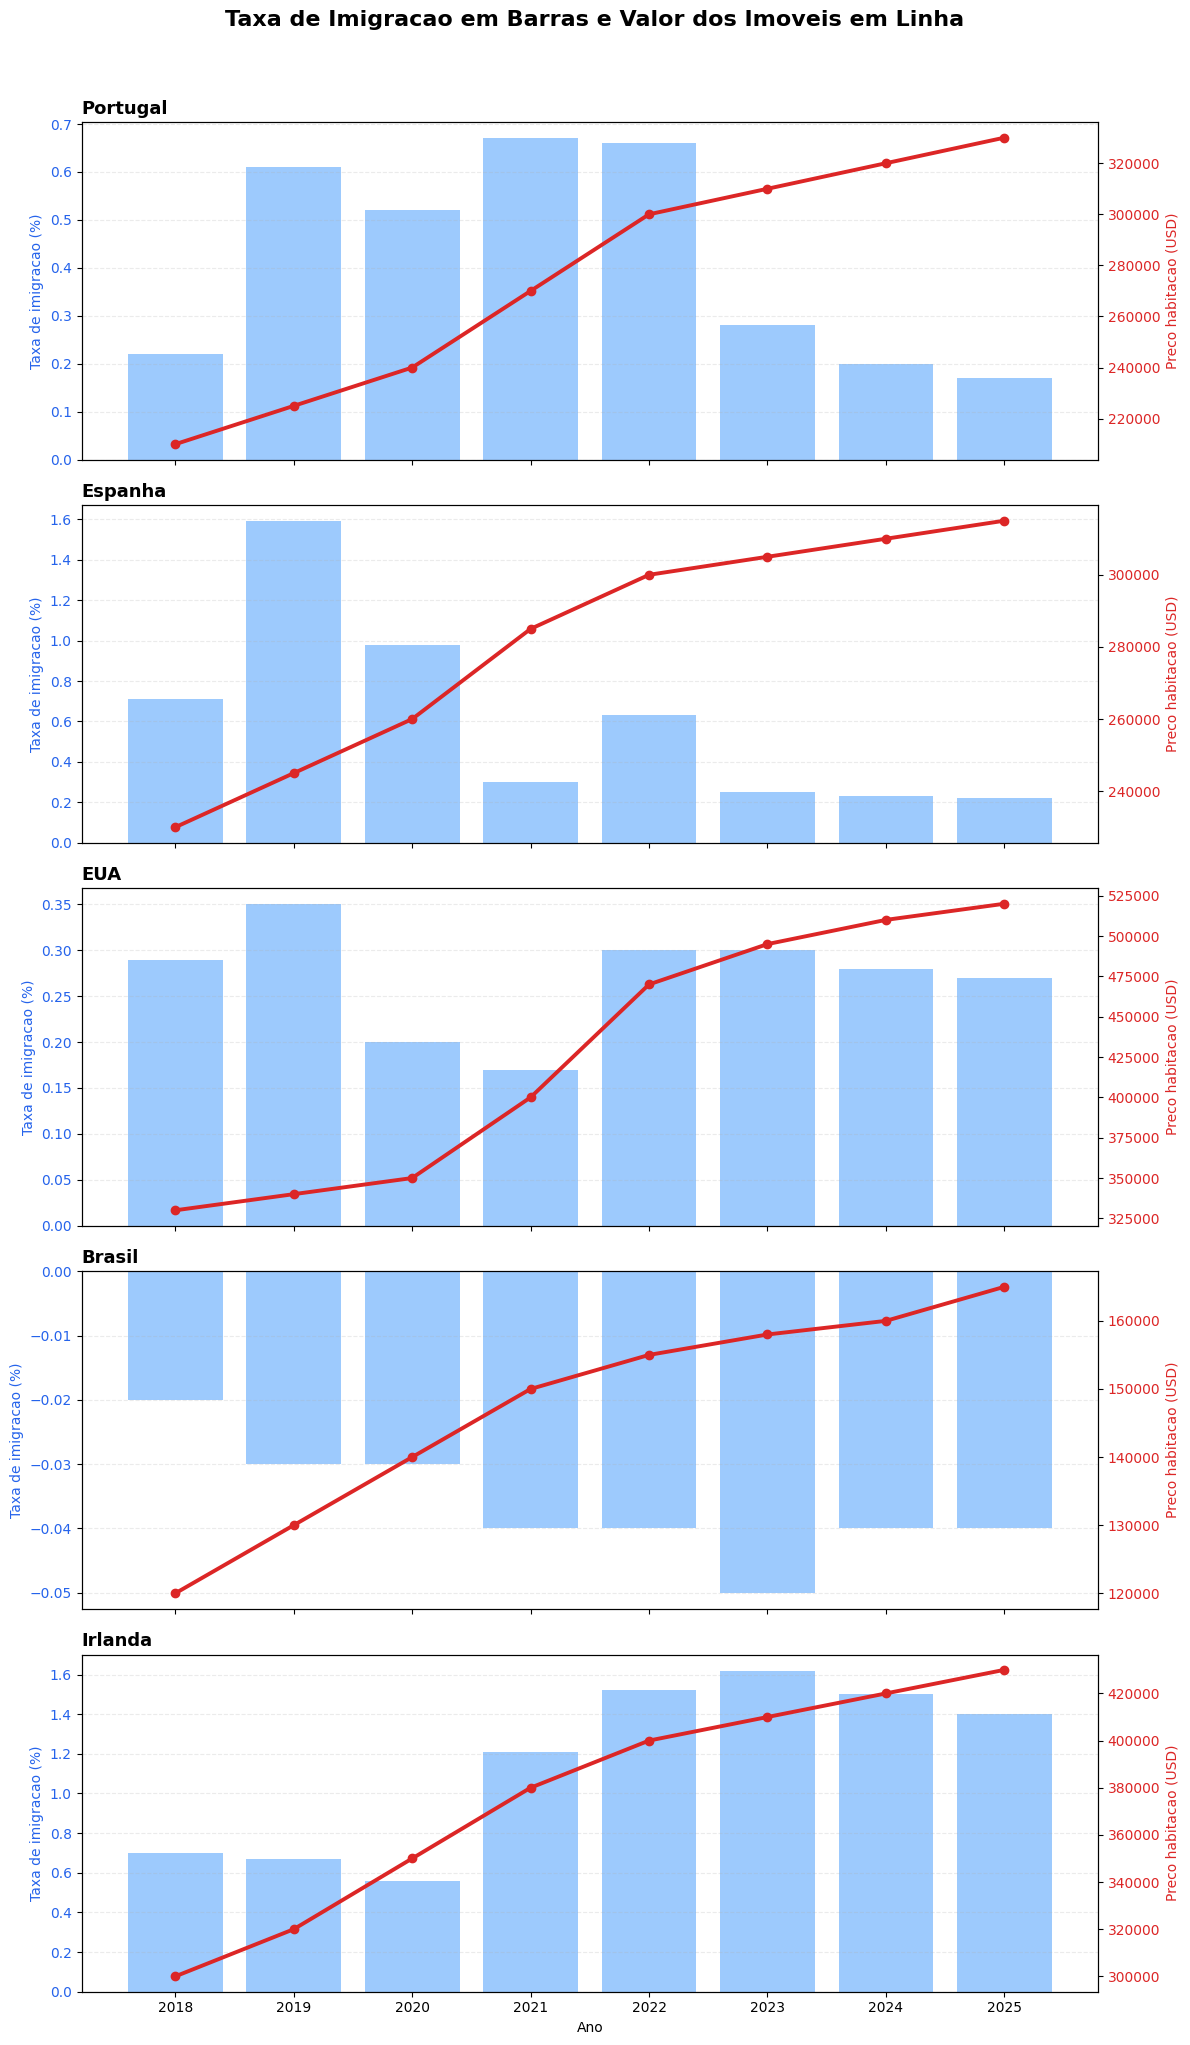

In [135]:
# Gráfico combinado: Imigracao em barras e Preco da Habitacao em linha
df = pd.read_csv("tabela_unificada_poder_compra_migracao.csv")
paises = df["pais"].unique()

fig, axes = plt.subplots(len(paises), 1, figsize=(12, 4 * len(paises)), sharex=True)

if len(paises) == 1:
    axes = [axes]

for ax, pais in zip(axes, paises):
    df_pais = df[df["pais"] == pais].sort_values("ano")

    ax.bar(
        df_pais["ano"],
        df_pais["taxa_imigracao_pct"],
        color="#93c5fd",
        alpha=0.9,
        label="Taxa de imigracao (%)"
    )
    ax.set_ylabel("Taxa de imigracao (%)", color="#2563eb")
    ax.tick_params(axis="y", labelcolor="#2563eb")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    ax2 = ax.twinx()
    ax2.plot(
        df_pais["ano"],
        df_pais["preco_medio_habitacao_usd"],
        color="#dc2626",
        marker="o",
        linewidth=2.8,
        label="Preco medio da habitacao"
    )
    ax2.set_ylabel("Preco habitacao (USD)", color="#dc2626")
    ax2.tick_params(axis="y", labelcolor="#dc2626")

    ax.set_title(pais, loc="left", fontsize=13, weight="bold")

axes[-1].set_xlabel("Ano")
plt.suptitle("Taxa de Imigracao em Barras e Valor dos Imoveis em Linha", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


# Criando um teste de Hipóteses

In [136]:
df = df.sort_values(["pais", "ano"]).copy()

# Garantir que as colunas estejam numéricas
df["imigracao_liquida"] = pd.to_numeric(df["imigracao_liquida"], errors="coerce")
df["preco_medio_habitacao_usd"] = pd.to_numeric(df["preco_medio_habitacao_usd"], errors="coerce")

# Criar a variacao percentual do preco por pais
df["variacao_preco_pct"] = (
    df.groupby("pais")["preco_medio_habitacao_usd"].pct_change() * 100
)

# Remover linhas com valores ausentes apenas nas colunas usadas no teste
df_teste = df.dropna(subset=["imigracao_liquida", "variacao_preco_pct"]).copy()

# Verificar se ha dados suficientes
if len(df_teste) < 3:
    print("Nao ha dados suficientes para realizar o teste de correlacao.")
else:
    x = df_teste["imigracao_liquida"]
    y = df_teste["variacao_preco_pct"]

    coef_corr, p_valor = pearsonr(x, y)

    print(f"Coeficiente de correlacao: {coef_corr:.4f}")
    print(f"p-valor: {p_valor:.4f}")

    alpha = 0.05

    if p_valor < alpha:
        print("Rejeitamos H0.")
        print("Ha evidencia estatistica de correlacao entre imigracao e subida dos precos.")
    else:
        print("Nao rejeitamos H0.")
        print("Nao ha evidencia estatistica suficiente de correlacao entre imigracao e subida dos precos.")



Coeficiente de correlacao: 0.1359
p-valor: 0.4362
Nao rejeitamos H0.
Nao ha evidencia estatistica suficiente de correlacao entre imigracao e subida dos precos.
